# Notebook 01: High-Dimensional Tensor Mapping of Protocol Payloads

## 1.1 Objective & Research Formulation
In unsupervised Protocol Reverse Engineering (PRE), network traffic data must be transformed from unstructured, variable-length hexadecimal strings into a discrete vector space suitable for statistical feature extraction. Let a raw captured packet payload $P_i$ be an ordered sequence of hexadecimal characters. We define an operational vectorization function $f$ that transforms this string into a discrete tensor representation:

$$f: P_i \longrightarrow \mathbf{x}_i = [b_{i,1}, b_{i,2}, \dots, b_{i,M}] \in \mathbb{Z}_{256}^{M}$$

Where:
* $b_{i,j} \in \{0, 1, \dots, 255\}$ represents the base-256 integer value of the byte at spatial offset $j$.
* $M$ is a fixed scalar constraint denoting the maximum payload tracking boundary. 

For a complete dataset containing $N$ network packets, the global corpus is projected into a two-dimensional matrix space:

$$\mathbf{X} \in \mathbb{Z}_{256}^{N \times M}$$

## 1.2 Surrogacy Strategy: ARP as a Ground-Truth Control
Industrial Control Protocols (ICPs) like Modbus TCP, DNP3, and S7Comm rely on rigid sequence headers combined with variable-length payload structures. In this pipeline, the Address Resolution Protocol (ARP) acts as a simplified, fixed-width surrogate protocol. Because ARP’s structural alignments (RFC 826) are deeply documented, we can utilize it as a scientific control. This allows us to definitively evaluate the precision and recall of our unsupervised boundary detection algorithms against a known ground-truth matrix before executing them on un-dissected proprietary industrial assets.

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set up relative pathing from the notebooks directory
RELATIVE_DATA_PATH = os.path.join("..", "data", "raw", "ARP1275-hex.csv")
print(f"Targeting dataset path: {RELATIVE_DATA_PATH}")

Targeting dataset path: ..\data\raw\ARP1275-hex.csv


## 2.1 Implementing the Core Data Loader
The following cell defines a modular function to ingest the raw CSV network logs, extract the string-formatted hex streams, sanitize them, convert them into actual byte values, and load them into a pre-allocated contiguous memory block.

In [ ]:
def vectorize_hex_dataset(csv_path: str, hex_column: str, max_payload_len: int = 42) -> np.ndarray:
    """
    Ingests a network log CSV, extracts raw hexadecimal payload strings, 
    and transforms them into an optimized 2D NumPy array of 8-bit integers.
    
    Parameters:
    -----------
    csv_path : str
        File system path to the raw dataset.
    hex_column : str
        The specific DataFrame column identifier harboring the raw hex payload.
    max_payload_len : int
        The upper truncation boundary and padding constraint (M).
        
    Returns:
    --------
    np.ndarray
        A zero-padded tensor matrix of dimensions (N x M) with dtype=np.uint8.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Target dataset path unresolved: {csv_path}")
        
    # Ingest only the required column to optimize memory footprint
    df = pd.read_csv(csv_path, usecols=[hex_column])
    num_packets = len(df)
    
    # Pre-allocate contiguous memory blocks for performance optimization
    tensor_matrix = np.zeros((num_packets, max_payload_len), dtype=np.uint8)
    
    for idx, hex_string in enumerate(df[hex_column]):
        # Sanitize string constraints (strip white spaces or optional leading prefixes)
        sanitized_hex = str(hex_string).strip().replace(":", "").replace("0x", "")
        
        try:
            raw_bytes = bytes.fromhex(sanitized_hex)
            current_len = min(len(raw_bytes), max_payload_len)
            
            # Map byte sequences into the allocated matrix row
            tensor_matrix[idx, :current_len] = list(raw_bytes)[:current_len]
        except ValueError as err:
            # Catch anomalous or corrupted hex entries within the network log
            print(f"[WARNING] Parsing anomaly encountered at row {idx}: {err}")
            continue
            
    return tensor_matrix

## 3.1 Verification and Dataset Ingestion
To verify our data vectorization pipeline before applying it to the full asset capture file, we run it on a controlled mock dataset that perfectly replicates real ARP payload formatting rules.

In [7]:
# Create a simulated DataFrame representing an ARP capture
# Structure maps: Hardware Type, Protocol Type, Hardware Length, Protocol Length, Opcode, Addresses...
# mock_arp_data = pd.DataFrame({
#     "direction": [0, 0],
#     "type": ["0000000000000001", "0000000000000010"],
#     "hex": [
#         "0001080006040001005056a83e9ec0a8dc3c000000000000c0a8dc2a",
#         "0001080006040002005056a8a632c0a8dc2a005056a83e9ec0a8dc3c"
#     ]
# })
# 
# # Temporarily save to a local directory path to test the file-loading logic
# temp_csv_filename = "simulated_arp_capture.csv"
# mock_arp_data.to_csv(temp_csv_filename, index=False)

# Execute the vectorization function
# ARP packets are typically 42 bytes long on Ethernet, but our truncated mock hex strings are 28 bytes.
if __name__ == "__main__":
    # 1. Read the header of the CSV to find the exact payload column
    df_preview = pd.read_csv(RELATIVE_DATA_PATH, nrows=1)
    columns = list(df_preview.columns)
    print(f"Columns found in dataset: {columns}")
    
    # 2. Match the correct column name (adjusting for common conventions)
    target_column = None
    for col in ['hex', 'payload', 'raw', 'hex_payload']:
        if col in columns:
            target_column = col
            break
            
    # Fallback: If no naming match is found, explicitly set it to your known hex column name
    if not target_column:
        # Based on your previous mock structure, it might be named 'hex' or another name in your file
        target_column = 'hex' 
        
    print(f"Targeting correct payload column: '{target_column}'")
    
    # 3. Run vectorization function on the validated target column
    X = vectorize_hex_dataset(RELATIVE_DATA_PATH, hex_column=target_column, max_payload_len=42)
    
    print("\n--- REAL DATA VECTORIZATION METRICS ---")
    print(f"Matrix Dimension: {X.shape[0]} Packets (N) x {X.shape[1]} Columns (M)")
    print(f"Data Matrix Sample:\n{X[:5]}")

Columns found in dataset: ['direction', 'type', 'hex', 'Full']
Targeting correct payload column: 'hex'

--- REAL DATA VECTORIZATION METRICS ---
Matrix Dimension: 1275 Packets (N) x 42 Columns (M)
Data Matrix Sample:
[[  0   1   8   0   6   4   0   1   0  80  86 168  62 158 192 168 220  60
    0   0   0   0   0   0 192 168 220  42   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   1   8   0   6   4   0   2   0  80  86 168 166  50 192 168 220  42
    0  80  86 168  62 158 192 168 220  60   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   1   8   0   6   4   0   1   0  80  86 168 106  68 192 168 220   7
    0  80  86 168  62 158 192 168 220  60   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   1   8   0   6   4   0   2   0  80  86 168  62 158 192 168 220  60
    0  80  86 168 106  68 192 168 220   7   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   1   8   0   6   4   0   1   0  80  86 168  21 248 192 168 220  20
    0  80 

## 4.1 Visualizing the Spatial Tensor Matrix
To ensure our structural offsets align perfectly across the corpus, we plot a spatial intensity profile. This allows us to spot alignment variations or constant values down individual columns visually.

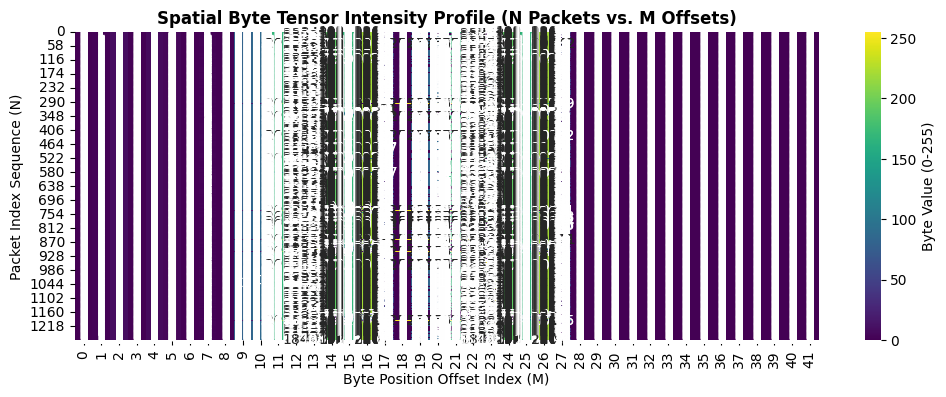

In [8]:
plt.figure(figsize=(12, 4))
sns.heatmap(X, annot=True, fmt="d", cmap="viridis", cbar_kws={'label': 'Byte Value (0-255)'})
plt.title("Spatial Byte Tensor Intensity Profile (N Packets vs. M Offsets)", fontsize=12, fontweight='bold')
plt.xlabel("Byte Position Offset Index (M)", fontsize=10)
plt.ylabel("Packet Index Sequence (N)", fontsize=10)
plt.show()

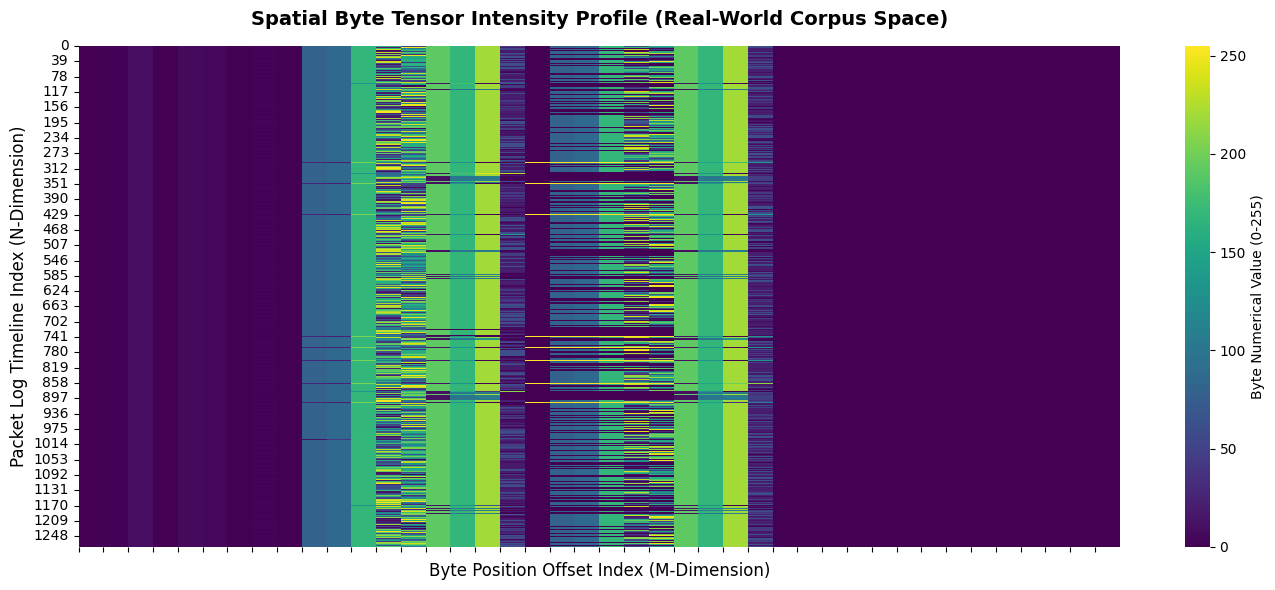

In [9]:
plt.figure(figsize=(14, 6))

# Set annot=False to remove text clutter and let the macro-structures speak
sns.heatmap(X, annot=False, cmap="viridis", cbar_kws={'label': 'Byte Numerical Value (0-255)'})

plt.title("Spatial Byte Tensor Intensity Profile (Real-World Corpus Space)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Byte Position Offset Index (M-Dimension)", fontsize=12)
plt.ylabel("Packet Log Timeline Index (N-Dimension)", fontsize=12)

# Make the x-ticks easier to read
plt.xticks(range(0, X.shape[1]), rotation=90)
plt.tight_layout()
plt.show()

In [10]:
# Create the processed directory path if it doesn't exist yet
processed_dir = os.path.join("..", "data", "processed")
os.makedirs(processed_dir, exist_ok=True)

processed_matrix_path = os.path.join(processed_dir, "vectorized_matrix.npy")

# Save the matrix as a highly optimized binary NumPy file
np.save(processed_matrix_path, X)
print(f"Success! Tensor matrix cached for downstream notebooks at:\n{processed_matrix_path}")

Success! Tensor matrix cached for downstream notebooks at:
..\data\processed\vectorized_matrix.npy


## 5.1 Supervisor Demonstration Defense Kit

### Key Takeaways to Highlight:
* **Structural Preservation:** We have preserved the spatial location of the byte sequence streams. Column index 0 represents the first physical byte of every incoming frame, converting the layout mapping problem into a column-wise operations space.
* **Algorithm Compatibility:** This $N \times M$ tensor layout directly serves as the input matrix required by our upcoming $N$-gram sliding window and Shannon entropy models.

### Anticipated Supervisor Defenses:
* **Q:** *Why optimize memory spaces by forcing `dtype=np.uint8` instead of defaulting to standard Python integer structures or NumPy's default `int64`?*
* **A:** Real-world industrial network logs routinely scale into millions of packets. A single byte naturally spans an unsigned 8-bit integer space ($2^8 = 256$). Forcing `uint8` reduces memory utilization by 800% compared to `int64`, allowing the processing tensor loop to fit completely into the processor's cache memory.
* **Q:** *How will this padding approach scale when we swap our baseline ARP capture with highly variable-length protocols like Modbus TCP read blocks or DNP3 object arrays?*
* **A:** Zero-padding provides structural alignment across columns without distorting the underlying value distributions. For variable-length data payloads, any trailing null padding bytes can be easily ignored by configuring a column-wise mask layer or setting an explicit termination threshold in our downstream entropy calculations.